<a href="https://colab.research.google.com/github/Sak04032007/ML-project-Insurance-smoker/blob/main/ML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving insurance.csv to insurance (1).csv
User uploaded file "insurance (1).csv" with length 55628 bytes


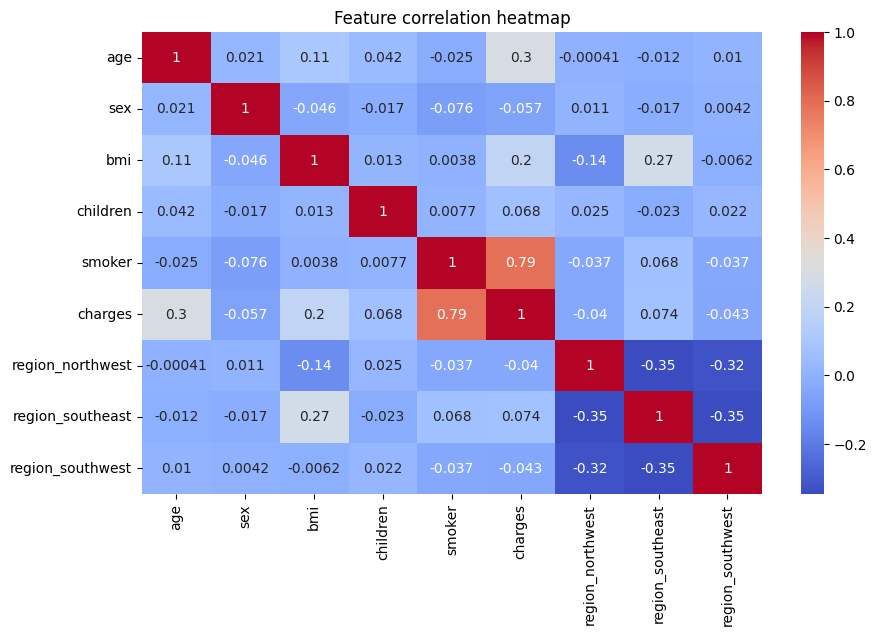

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.metrics import mean_absolute_error , accuracy_score , r2_score , confusion_matrix , classification_report

df = pd.read_csv('insurance.csv')
df['smoker'] = df['smoker'].map({'yes': 1 , 'no':0})
df['sex'] = df['sex'].map({'female':1 , 'male': 0})
df = pd.get_dummies(df, columns=['region'], drop_first=True)
#print(df.head())

mt.figure(figsize = (10,6))
sns.heatmap(df.corr() , annot = True , cmap = 'coolwarm')
mt.title("Feature correlation heatmap")
#mt.show()

X = df.drop('charges' , axis =1)
Y_reg = df['charges']
X_train , X_test , Y_train , Y_test = train_test_split( X, Y_reg , test_size = 0.2 , random_state = 42)


X_smoke = df.drop('smoker' , axis =1)
Y_smoke = df['smoker']
X_smoke_train , X_smoke_test , Y_smoke_train , Y_smoke_test = train_test_split( X_smoke, Y_smoke , test_size = 0.2 , random_state = 42)
Log_R = LogisticRegression(max_iter = 1000)
Log_R.fit(X_smoke_train , Y_smoke_train)
Y_predict1 = Log_R.predict(X_smoke_test)




In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_train,Y_train)
Y_pred = lin_reg.predict(X_test)
print("Successfully trained the model")

Successfully trained the model


In [8]:
MeEr = mean_absolute_error(Y_test , Y_pred)
R2D2 = r2_score(Y_test , Y_pred)
print(f"Mean absolute error is ${MeEr:.2f} ")
print(f"R-squared score is {R2D2:.4f}")



Mean absolute error is $4181.19 
R-squared score is 0.7836


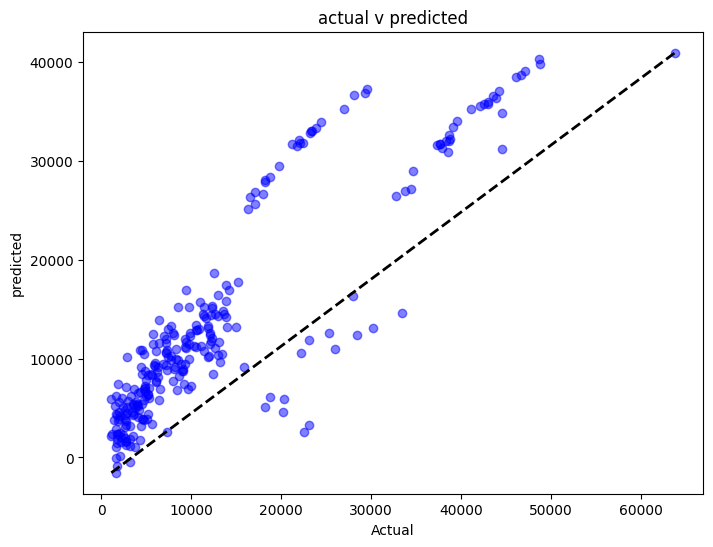

In [9]:
mt.figure(figsize=(8,6))
mt.scatter(Y_test , Y_pred , alpha =0.5 , color = 'blue')
mt.plot([Y_test.min() , Y_test.max()] , [Y_pred.min() , Y_pred.max() ] ,'k--' , lw =2)
mt.xlabel("Actual")
mt.ylabel("predicted")
mt.title("actual v predicted")
mt.show()

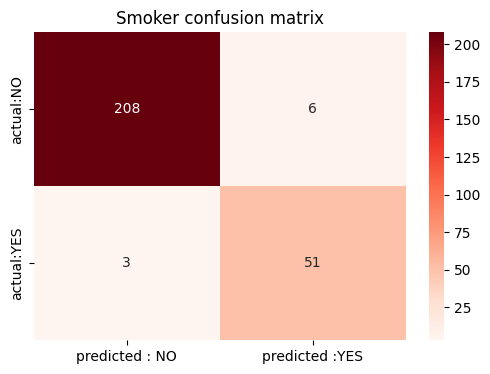

In [10]:
cm = confusion_matrix(Y_smoke_test , Y_predict1)
mt.figure(figsize = (6,4))
sns.heatmap(cm , annot = True , fmt = 'd' , cmap = 'Reds',
xticklabels = ['predicted : NO' , 'predicted :YES'],
yticklabels = ['actual:NO' , 'actual:YES'])
mt.title('Smoker confusion matrix')
mt.show()

In [11]:
import pandas as pd
import numpy as np


print("\n--- Predict Insurance Charges ---")
age_input = int(input("Enter age: "))
sex_input = input("Enter sex (male/female): ")
bmi_input = float(input("Enter BMI: "))
children_input = int(input("Enter number of children: "))
smoker_input_for_charges = input("Is the person a smoker? (yes/no): ")
region_input = input("Enter region (northeast, northwest, southeast, southwest): ")

sex_mapped = 1 if sex_input.lower() == 'female' else 0
smoker_mapped_for_charges = 1 if smoker_input_for_charges.lower() == 'yes' else 0

region_northeast = 0
region_northwest = 0
region_southeast = 0
region_southwest = 0

if region_input.lower() == 'northeast':
    region_northeast = 1
elif region_input.lower() == 'northwest':
    region_northwest = 1
elif region_input.lower() == 'southeast':
    region_southeast = 1
elif region_input.lower() == 'southwest':
    region_southwest = 1


new_data_charges = pd.DataFrame({
    'age': [age_input],
    'sex': [sex_mapped],
    'bmi': [bmi_input],
    'children': [children_input],
    'smoker': [smoker_mapped_for_charges],
    'region_northwest': [1 if region_input.lower() == 'northwest' else 0],
    'region_southeast': [1 if region_input.lower() == 'southeast' else 0],
    'region_southwest': [1 if region_input.lower() == 'southwest' else 0]
})

predicted_charge = lin_reg.predict(new_data_charges)
print(f"Predicted insurance charges: ${predicted_charge[0]:.2f}")


print("\n--- Predict Smoker Status ---")
age_input_smoke = int(input("Enter age for smoker prediction: "))
sex_input_smoke = input("Enter sex (male/female) for smoker prediction: ")
bmi_input_smoke = float(input("Enter BMI for smoker prediction: "))
children_input_smoke = int(input("Enter number of children for smoker prediction: "))
charges_input_smoke = float(input("Enter charges for smoker prediction: "))
region_input_smoke = input("Enter region (northeast, northwest, southeast, southwest) for smoker prediction: ")

sex_mapped_smoke = 1 if sex_input_smoke.lower() == 'female' else 0

new_data_smoke = pd.DataFrame({
    'age': [age_input_smoke],
    'sex': [sex_mapped_smoke],
    'bmi': [bmi_input_smoke],
    'children': [children_input_smoke],
    'charges': [charges_input_smoke],
    'region_northwest': [1 if region_input_smoke.lower() == 'northwest' else 0],
    'region_southeast': [1 if region_input_smoke.lower() == 'southeast' else 0],
    'region_southwest': [1 if region_input_smoke.lower() == 'southwest' else 0]
})


predicted_smoker_proba = Log_R.predict_proba(new_data_smoke)[:, 1]
predicted_smoker_class = Log_R.predict(new_data_smoke)[0]

print(f"Probability of being a smoker: {predicted_smoker_proba[0]:.2f}")
print(f"Predicted smoker status: {'Yes' if predicted_smoker_class == 1 else 'No'}")


--- Predict Insurance Charges ---
Enter age: 19
Enter sex (male/female): male
Enter BMI: 27
Enter number of children: 1
Is the person a smoker? (yes/no): no
Enter region (northeast, northwest, southeast, southwest): northeast
Predicted insurance charges: $2459.51

--- Predict Smoker Status ---
Enter age for smoker prediction: 29
Enter sex (male/female) for smoker prediction: male
Enter BMI for smoker prediction: 26
Enter number of children for smoker prediction: 1
Enter charges for smoker prediction: 2000
Enter region (northeast, northwest, southeast, southwest) for smoker prediction: northeast
Probability of being a smoker: 0.00
Predicted smoker status: No


In [15]:
!echo "# ML-project-Insurance-smoker" >> README.md
!git init
!git add README.md
!git commit -m "first commit"
!git branch -M main
!git remote add origin https://github.com/Sak04032007/ML-project-Insurance-smoker.git
!git push -u origin main

Reinitialized existing Git repository in /content/.git/
[main (root-commit) 2a99897] first commit
 1 file changed, 2 insertions(+)
 create mode 100644 README.md
error: remote origin already exists.
fatal: could not read Username for 'https://github.com': No such device or address


In [14]:
!git config --global user.email "susaksham48@gmail.com"
!git config --global user.name "Sak04032007"